# Facial Recognition System using EfficientNet and MTCNN

In [1]:
# Title: Face Recognition System using LFW Dataset
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install tensorflow mtcnn scikit-learn tensorflow_hub -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.3 MB/s eta 0:00:00


## Import Required Libraries

In [2]:
# Standard Libraries
import os
import random
import pickle
import tarfile
import requests

# Numerical Libraries
import numpy as np

# Deep Learning
import tensorflow as tf
import tensorflow_hub as hub

# Face Detection
from mtcnn import MTCNN

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Visualization
import matplotlib.pyplot as plt

# Image Processing
import cv2

# Utilities
from tqdm.notebook import tqdm

## Face Recognition System

In [3]:
class FaceRecognitionSystem:
    def __init__(self):
        self.detector = MTCNN()
        # Load EfficientNet model directly using KerasLayer wrapper
        self.facenet_model_layer = hub.KerasLayer('https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2')
        self.required_size = (160, 160)
        self.embeddings = []
        self.labels = []
        self.le = LabelEncoder()
        self.classifier = SVC(kernel="linear", C=0.1, probability=True)

    def _extract_face(self, image):
        faces = self.detector.detect_faces(image)
        if not faces:
            return None

        x1, y1, width, height = faces[0]['box']
        x2, y2 = x1 + width, y1 + height

        face = image[y1:y2, x1:x2]
        face = cv2.resize(face, self.required_size)
        return face

    def _get_embedding(self, face):
        # Preprocess the face image
        face = face.astype('float32') / 255.0 # Normalize pixel values
        face = (face - 0.5) * 2.0  # Scale to [-1,1] if required

        # Add batch dimension and get embedding
        face_tensor = tf.convert_to_tensor([face])
        embedding = self.facenet_model_layer(face_tensor)
        return embedding.numpy()[0]

    def process_dataset(self, dataset_path, max_samples_per_person=20):
        person_samples = {}

        # First, find eligible people (those with enough samples)
        for person_name in os.listdir(dataset_path):
            person_dir = os.path.join(dataset_path, person_name)
            if os.path.isdir(person_dir):
                images = [f for f in os.listdir(person_dir)
                         if f.endswith(('.jpg', '.jpeg', '.png'))][:max_samples_per_person]
                if len(images) >= 5:  # Only include people with at least 5 images
                    person_samples[person_name] = images

        print(f"Found {len(person_samples)} people with sufficient samples")

        # Process faces for each eligible person
        for person_name, images in tqdm(person_samples.items(), desc="Processing people"):
            successful_embeddings = 0
            for image_name in images:
                try:
                    image_path = os.path.join(dataset_path, person_name, image_name)
                    image = cv2.imread(image_path)
                    if image is None:
                        continue

                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    face = self._extract_face(image)

                    if face is not None:
                        embedding = self._get_embedding(face)
                        self.embeddings.append(embedding)
                        self.labels.append(person_name)
                        successful_embeddings += 1
                except Exception as e:
                    print(f"Error processing {image_path}: {str(e)}")

            if successful_embeddings > 0:
                print(f"Processed {successful_embeddings} images for {person_name}")

    def train_classifier(self):
        if len(self.embeddings) == 0:
            print("No embeddings to train on!")
            return None

        X = np.array(self.embeddings)
        encoded_labels = self.le.fit_transform(self.labels)

        X_train, X_test, y_train, y_test = train_test_split(
            X, encoded_labels, test_size=0.2, random_state=42
        )

        self.classifier.fit(X_train, y_train)

        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        return {
            'accuracy': accuracy,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'y_pred': y_pred
        }


## Visualization Functions

In [4]:
def plot_results(results):
    if results is None:
        print("No results to plot!")
        return

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.title('Training Data Distribution')
    unique, counts = np.unique(results['y_train'], return_counts=True)
    plt.bar(unique[:10], counts[:10])  # Plot only first 10 classes for visibility
    plt.xlabel('Person ID (first 10)')
    plt.ylabel('Number of samples')

    plt.subplot(1, 2, 2)
    plt.title(f"Model Accuracy: {results['accuracy']:.2%}")
    cm = tf.math.confusion_matrix(results['y_test'], results['y_pred'])
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar()
    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    plt.tight_layout()
    plt.show()


## Model Training

Initializing Face Recognition System...
Processing dataset...
Found 423 people with sufficient samples


Processing people:   0%|          | 0/423 [00:00<?, ?it/s]

Processed 6 images for Christine_Todd_Whitman
Processed 5 images for Christine_Baumgartner
Processed 5 images for Choi_Sung-hong
Processed 5 images for Chen_Shui-bian
Processed 6 images for Charlton_Heston
Processed 13 images for Charles_Moose
Processed 9 images for Charles_Taylor
Processed 8 images for Celine_Dion
Processed 5 images for Chanda_Rubin
Processed 8 images for Cesar_Gaviria
Processed 5 images for Catherine_Deneuve
Processed 11 images for Catherine_Zeta-Jones
Processed 5 images for Carrie-Anne_Moss
Processed 6 images for Carmen_Electra
Processed 19 images for Carlos_Moya
Processed 20 images for Carlos_Menem
Processed 5 images for Carla_Del_Ponte
Processed 6 images for Calista_Flockhart
Processed 6 images for Cameron_Diaz
Processed 6 images for Bulent_Ecevit
Processed 13 images for Britney_Spears
Processed 5 images for Brad_Johnson
Processed 6 images for Boris_Becker
Processed 7 images for Bob_Stoops
Processed 6 images for Bob_Graham
Processed 8 images for Bob_Hope
Processed

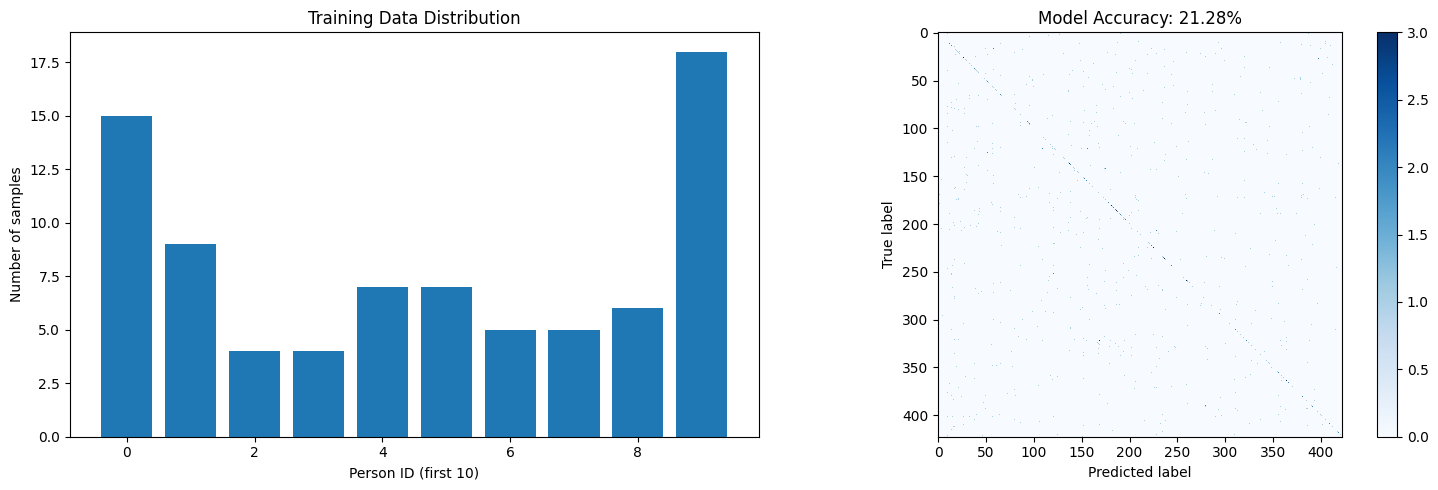


Classification Report:
                              precision    recall  f1-score   support

                Abdullah_Gul       0.30      0.75      0.43         4
                Adrien_Brody       0.00      0.00      0.00         3
               Ahmed_Chalabi       0.00      0.00      0.00         1
                 Ai_Sugiyama       0.00      0.00      0.00         1
                     Al_Gore       0.00      0.00      0.00         1
            Alejandro_Toledo       0.00      0.00      0.00         2
                   Ali_Naimi       0.00      0.00      0.00         3
               Allyson_Felix       1.00      0.50      0.67         2
                Alvaro_Uribe       0.40      0.40      0.40         5
                 Amelia_Vega       0.00      0.00      0.00         1
             Amelie_Mauresmo       0.18      0.50      0.27         4
                 Ana_Guevara       0.00      0.00      0.00         1
                 Ana_Palacio       0.00      0.00      0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Model saved to Google Drive: /content/drive/MyDrive/face_recognition_model.pkl


In [5]:
try:
    # Initialize system and process dataset
    print("Initializing Face Recognition System...")
    face_system = FaceRecognitionSystem()

    print("Processing dataset...")
    dataset_path = '/content/drive/MyDrive/lfw'
    face_system.process_dataset(dataset_path, max_samples_per_person=20)

    # Train classifier and get results
    print(f"Training classifier on {len(face_system.embeddings)} samples...")
    results = face_system.train_classifier()

    if results is not None:
        # Plot and display results
        plot_results(results)

        # Print classification report
        y_true = face_system.le.inverse_transform(results['y_test'])
        y_pred = face_system.le.inverse_transform(results['y_pred'])
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred))

        # Save model
        save_path = '/content/drive/MyDrive/face_recognition_model.pkl'
        if os.path.exists('/content/drive'):
            import pickle
            model_data = {
                'classifier': face_system.classifier,
                'label_encoder': face_system.le
            }
            with open(save_path, 'wb') as f:
                pickle.dump(model_data, f)
            print(f"Model saved to Google Drive: {save_path}")
    else:
        print("Training failed due to lack of data.")

except Exception as e:
    print(f"An error occurred: {str(e)}")
    raise

## Face Recognition Demo

In [6]:
class FaceRecognitionDemo:
    def __init__(self, model_path):
        # Load the saved model and components
        with open(model_path, 'rb') as f:
            model_data = pickle.load(f)

        self.classifier = model_data['classifier']
        self.le = model_data['label_encoder']
        self.detector = MTCNN()

        # Load EfficientNet model using KerasLayer
        self.facenet_model_layer = hub.KerasLayer('https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2')
        self.required_size = (160, 160)

    def process_image(self, image):
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        faces = self.detector.detect_faces(rgb_image)

        if not faces:
            return None, None

        x1, y1, width, height = faces[0]['box']
        x2, y2 = x1 + width, y1 + height

        face = rgb_image[y1:y2, x1:x2]
        face_resized = cv2.resize(face, self.required_size)

        # Normalize and scale image to [-1, 1]
        face_array = face_resized.astype('float32') / 255.0
        face_normalized = (face_array - 0.5) * 2.0

        # Prepare input for EfficientNet
        face_tensor = tf.convert_to_tensor([face_normalized])
        embedding = self.facenet_model_layer(face_tensor).numpy()[0]

        return embedding, (x1, y1, x2, y2)

    def predict(self, image):
        embedding, face_box = self.process_image(image)
        if embedding is None:
            return None, None, None

        # Predict
        pred_proba = self.classifier.predict_proba([embedding])[0]
        pred_class = np.argmax(pred_proba)
        confidence = pred_proba[pred_class]
        predicted_name = self.le.inverse_transform([pred_class])[0]

        return predicted_name, confidence, face_box

In [7]:
def get_random_test_images(lfw_path, num_images=5):
    all_people = [d for d in os.listdir(lfw_path) if os.path.isdir(os.path.join(lfw_path, d))]
    selected_people = random.sample(all_people, num_images)

    test_images = []
    for person in selected_people:
        person_dir = os.path.join(lfw_path, person)
        images = os.listdir(person_dir)
        selected_image = random.choice(images)
        image_path = os.path.join(person_dir, selected_image)
        image = cv2.imread(image_path)
        test_images.append((person, image))

    return test_images

## Testing the Model

In [8]:
def display_results(test_images, predictions):
    plt.figure(figsize=(20, 4))
    for i, ((true_name, image), (pred_name, confidence, face_box)) in enumerate(zip(test_images, predictions)):
        plt.subplot(1, len(test_images), i+1)

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if face_box:
            x1, y1, x2, y2 = face_box
            cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)

        plt.imshow(image_rgb)
        if pred_name is None:
            result_text = f"True: {true_name}\nNo face detected"
        else:
            result_text = f"True: {true_name}\nPred: {pred_name}\nConf: {confidence:.2%}"
        plt.title(result_text, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## Prediction Results

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Initializing demo system...
Getting test images...
Making predictions...
Displaying results...


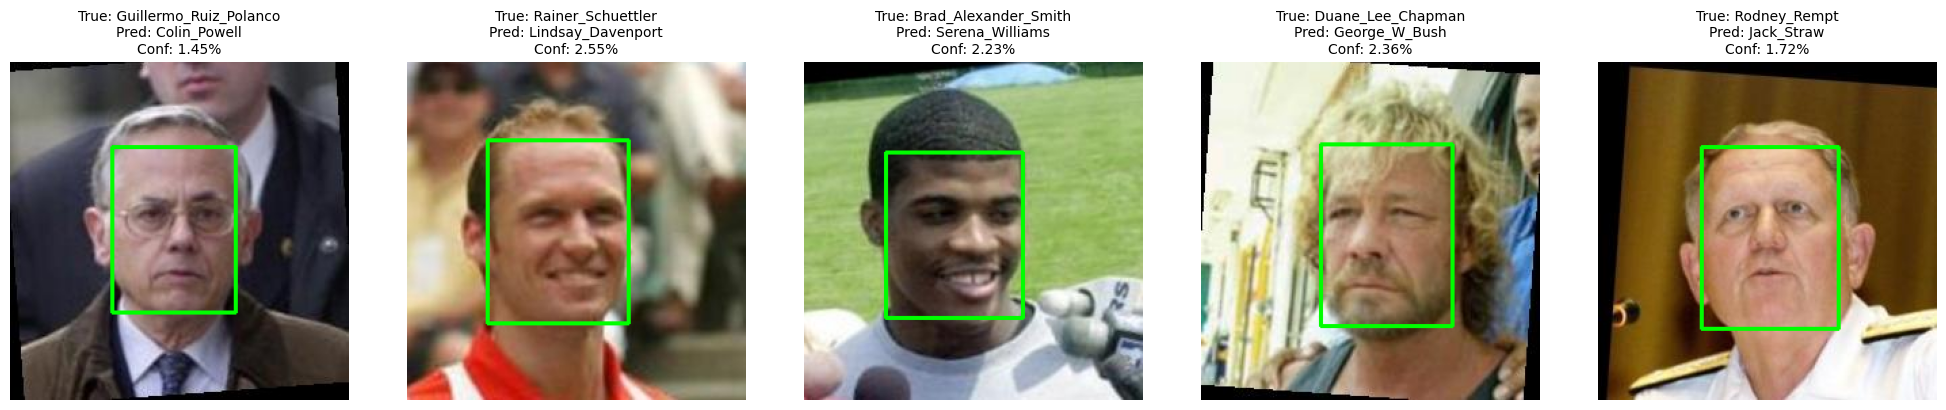


Test Accuracy: 0.00%

Detailed Results:
✗ True: Guillermo_Ruiz_Polanco Predicted: Colin_Powell         Confidence: 1.45%
✗ True: Rainer_Schuettler    Predicted: Lindsay_Davenport    Confidence: 2.55%
✗ True: Brad_Alexander_Smith Predicted: Serena_Williams      Confidence: 2.23%
✗ True: Duane_Lee_Chapman    Predicted: George_W_Bush        Confidence: 2.36%
✗ True: Rodney_Rempt         Predicted: Jack_Straw           Confidence: 1.72%


In [9]:
try:
    # Mount Google Drive to access the saved model
    drive.mount('/content/drive')
    model_path = '/content/drive/MyDrive/face_recognition_model.pkl'

    # Initialize the demo system
    print("Initializing demo system...")
    demo_system = FaceRecognitionDemo(model_path)

    # Get random test images
    print("Getting test images...")
    lfw_path = '/content/drive/MyDrive/lfw'
    test_images = get_random_test_images(lfw_path, num_images=5)

    # Make predictions
    print("Making predictions...")
    predictions = []
    for _, image in test_images:
        pred_name, confidence, face_box = demo_system.predict(image)
        predictions.append((pred_name, confidence, face_box))

    # Display results
    print("Displaying results...")
    display_results(test_images, predictions)

    # Calculate and display metrics
    correct_predictions = sum(1 for (true_name, _), (pred_name, _, _)
                                in zip(test_images, predictions)
                                if pred_name is not None and true_name == pred_name)
    total_predictions = sum(1 for (_, _, _) in predictions if _ is not None)

    if total_predictions > 0:
        accuracy = correct_predictions / total_predictions
        print(f"\nTest Accuracy: {accuracy:.2%}")
    else:
        print("\nNo valid predictions made")

    # Display detailed results
    print("\nDetailed Results:")
    for (true_name, _), (pred_name, confidence, _) in zip(test_images, predictions):
        if pred_name is None:
            print(f"✗ True: {true_name:<20} No face detected")
        else:
            status = "✓" if true_name == pred_name else "✗"
            print(f"{status} True: {true_name:<20} Predicted: {pred_name:<20} Confidence: {confidence:.2%}")

except Exception as e:
    print(f"An error occurred: {str(e)}")
    raise